In [10]:


import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")


def load_data(): 
    col_names = [
        "age", "sex", "cp", "trestbps", "chol", "fbs",
        "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
    ]
    
    base_path = os.path.expanduser("~/Desktop/STAT238PROJECT/STAT238_FINALPROJECT/heart+disease")
    
    files = {
        0: "processed.cleveland.data",
        1: "processed.hungarian.data",
        2: "processed.switzerland.data",
        3: "processed.va.data",
    }
    hospital_names = {0: "Cleveland", 1: "Hungarian", 2: "Switzerland", 3: "VA Long Beach"}
    
    dfs = []
    for hosp_id, fname in files.items():
        path = os.path.join(base_path, fname)
        df = pd.read_csv(path, header=None, names=col_names, na_values="?")
        df["hospital"] = hosp_id
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index=True)
    data["target"] = (data["target"] > 0).astype(int)
    
    feature_cols = ["age", "sex", "cp", "trestbps", "chol", "fbs",
                    "restecg", "thalach", "exang", "oldpeak"]
    data = data.dropna(subset=feature_cols)
    
    print(f"Dataset shape: {data.shape}")
    print(data.groupby("hospital")["target"].agg(["count", "mean"]))
    
    return data, hospital_names



In [11]:
data, hospital_names = load_data()
print(data.shape)
print(data.head())

Dataset shape: (740, 15)
          count      mean
hospital                 
0           303  0.458746
1           261  0.375479
2            46  0.978261
3           130  0.776923
(740, 15)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  hospital  
0    3.0  0.0   6.0       0         0  
1    2.0  3.0   3.0       1         0  
2    2.0  2.0   7.0       1         0  
3    3.0  0.0   3.0       0         0  
4    1.0  0.0   3.0       0         0  


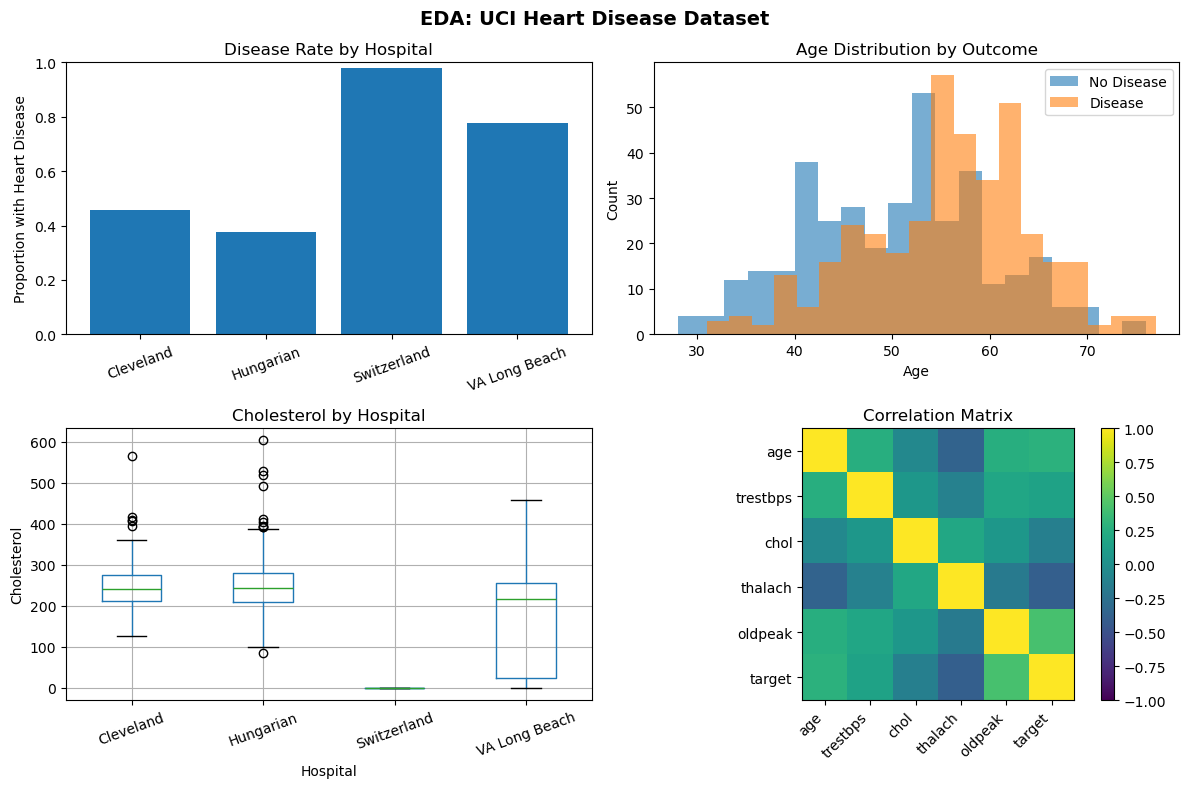

EDA plot saved to eda.png


In [12]:
def plot_eda(data, hospital_names):
    data = data.copy()
    data["hospital_name"] = data["hospital"].map(hospital_names)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("EDA: UCI Heart Disease Dataset", fontsize=14, fontweight="bold")

    # Disease rate per hospital
    rates = data.groupby("hospital_name")["target"].mean()

    axes[0, 0].bar(rates.index, rates.values)
    axes[0, 0].set_title("Disease Rate by Hospital")
    axes[0, 0].set_ylabel("Proportion with Heart Disease")
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].tick_params(axis="x", rotation=20)

    # Age distribution by outcome
    axes[0, 1].hist(
        data.loc[data["target"] == 0, "age"],
        bins=20,
        alpha=0.6,
        label="No Disease"
    )
    axes[0, 1].hist(
        data.loc[data["target"] == 1, "age"],
        bins=20,
        alpha=0.6,
        label="Disease"
    )
    axes[0, 1].set_title("Age Distribution by Outcome")
    axes[0, 1].set_xlabel("Age")
    axes[0, 1].set_ylabel("Count")
    axes[0, 1].legend()

    # Cholesterol by hospital
    data.boxplot(column="chol", by="hospital_name", ax=axes[1, 0])
    axes[1, 0].set_title("Cholesterol by Hospital")
    axes[1, 0].set_xlabel("Hospital")
    axes[1, 0].set_ylabel("Cholesterol")
    axes[1, 0].tick_params(axis="x", rotation=20)

    # restructure plot layout and title
    fig.suptitle("EDA: UCI Heart Disease Dataset", fontsize=14, fontweight="bold")

    # Correlation heatmap
    numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
    corr = data[numeric_cols].corr()

    im = axes[1, 1].imshow(corr, vmin=-1, vmax=1)
    axes[1, 1].set_title("Correlation Matrix")
    axes[1, 1].set_xticks(range(len(numeric_cols)))
    axes[1, 1].set_yticks(range(len(numeric_cols)))
    axes[1, 1].set_xticklabels(numeric_cols, rotation=45, ha="right")
    axes[1, 1].set_yticklabels(numeric_cols)

    plt.colorbar(im, ax=axes[1, 1])

    plt.tight_layout()
    plt.savefig("eda.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("EDA plot saved to eda.png")
plot_eda(data, hospital_names)

In [13]:

# 3. BASELINE MODELS

def complete_pooling_model(X, y, hospital, n_hospitals):
    """Bayesian logistic regression ignoring hospital membership."""
    
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=0, sigma=2)
        beta = pm.Normal("beta", mu=0, sigma=2, shape=X.shape[1])

        logit_p = alpha + pm.math.dot(X, beta)

        y_obs = pm.Bernoulli(
            "y_obs",
            logit_p=logit_p,
            observed=y
        )

        trace = pm.sample(
            draws=1000,
            tune=1000,
            target_accept=0.9,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True},
            random_seed=42
        )

    return model, trace


def no_pooling_model(X, y, hospital, n_hospitals):
    """Bayesian logistic regression with separate hospital-specific parameters."""
    
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=0, sigma=2, shape=n_hospitals)

        beta = pm.Normal(
            "beta",
            mu=0,
            sigma=2,
            shape=(n_hospitals, X.shape[1])
        )

        logit_p = alpha[hospital] + pm.math.sum(beta[hospital] * X, axis=1)

        y_obs = pm.Bernoulli(
            "y_obs",
            logit_p=logit_p,
            observed=y
        )

        trace = pm.sample(
            draws=1000,
            tune=1000,
            target_accept=0.9,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True},
            random_seed=42
        )

    return model, trace

In [14]:
feature_cols = ["age", "sex", "cp", "trestbps", "chol",
                "fbs", "restecg", "thalach", "exang", "oldpeak"]

X = data[feature_cols].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

y = data["target"].values
hospital = data["hospital"].values
n_hospitals = data["hospital"].nunique()

In [15]:

# 4. HIERARCHICAL MODEL (MAIN MODEL)
def hierarchical_model(X, y, hospital, n_hospitals):
    """
    Bayesian hierarchical logistic regression.

    Level 1: patient outcome follows a Bernoulli model
    Level 2: hospital intercepts are partially pooled
    Level 3: hyperpriors control the overall hospital distribution
    """

    with pm.Model() as model:
        # Hyperpriors
        mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=1)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1)

        # Hospital-specific intercepts using non-centered parameterization
        alpha_offset = pm.Normal(
            "alpha_offset",
            mu=0,
            sigma=1,
            shape=n_hospitals
        )

        alpha = pm.Deterministic(
            "alpha",
            mu_alpha + sigma_alpha * alpha_offset
        )

        # Shared feature effects
        beta = pm.Normal(
            "beta",
            mu=0,
            sigma=1,
            shape=X.shape[1]
        )

        # Linear predictor
        logit_p = alpha[hospital] + pm.math.dot(X, beta)

        # Likelihood
        y_obs = pm.Bernoulli(
            "y_obs",
            logit_p=logit_p,
            observed=y
        )

        trace = pm.sample(
            draws=2000,
            tune=1000,
            target_accept=0.92,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True},
            random_seed=42,
            progressbar=True
        )

    return model, trace

In [16]:

# 5. DIAGNOSTICS

def run_diagnostics(trace, model_name="Hierarchical"):
    print(f"\n{'='*50}")
    print(f"DIAGNOSTICS: {model_name}")
    print(f"{'='*50}")

    # R-hat
    rhat = az.rhat(trace)

    print("\nR-hat summary:")
    for var in rhat.data_vars:
        max_rhat = float(rhat[var].max())
        flag = "WARN" if max_rhat > 1.01 else "OK"
        print(f"  {var}: max R-hat = {max_rhat:.4f} [{flag}]")

    # Divergences
    n_divergences = int(trace.sample_stats["diverging"].sum())

    print(f"\nDivergences: {n_divergences}")
    # Effective sample size
    ess = az.ess(trace)

    print("\nEffective Sample Size:")
    for var in ess.data_vars:
        min_ess = float(ess[var].min())
        flag = "LOW" if min_ess < 400 else "OK"
        print(f"  {var}: min ESS = {min_ess:.0f} [{flag}]")

    # Possible variables in the trace
    possible_vars = ["mu_alpha", "sigma_alpha", "alpha", "beta"]
    var_names = [v for v in possible_vars if v in trace.posterior.data_vars]

    # Trace plots
    az.plot_trace(trace, var_names=var_names)
    plt.suptitle(f"Trace Plots: {model_name}", y=1.02)
    plt.tight_layout()

    file_name = f"trace_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(file_name, dpi=120, bbox_inches="tight")
    plt.show()

    print(f"Trace plot saved to {file_name}")

In [17]:

# 6. MODEL COMPARISON (LOO-CV)
def compare_models(traces_dict):
  
    print("\n" + "="*50)
    print("MODEL COMPARISON: LOO-CV")
    print("="*50)
    
    comparison = az.compare(traces_dict, ic="loo", scale="deviance")
    print(comparison)
    
    az.plot_compare(comparison)
    plt.title("LOO-CV Model Comparison")
    plt.tight_layout()
    plt.savefig("loo_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    return comparison




In [18]:

# 7. FREQUENTIST BASELINE
def frequentist_baseline(X, y):
    """Standard sklearn logistic regression with 5-fold CV for comparison."""
    lr = LogisticRegression(max_iter=1000, random_state=42)
    auc_scores = cross_val_score(lr, X, y, cv=5, scoring="roc_auc")
    acc_scores = cross_val_score(lr, X, y, cv=5, scoring="accuracy")
    print(f"\nFrequentist Logistic Regression (5-fold CV):")
    print(f"  ROC-AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
    print(f"  Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
    return lr



# 8. POSTERIOR ANALYSIS
def plot_hospital_effects(trace, hospital_names):
    """Plot posterior distributions of hospital-specific intercepts."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    alpha_samples = trace.posterior["alpha"].values  # shape: (chains, draws, n_hospitals)
    alpha_flat = alpha_samples.reshape(-1, alpha_samples.shape[-1])
    
    colors = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]
    for i, (hid, hname) in enumerate(hospital_names.items()):
        ax.hist(alpha_flat[:, i], bins=50, alpha=0.6, label=hname, color=colors[i], density=True)
    
    ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Zero")
    ax.set_xlabel("Hospital Intercept (log-odds)")
    ax.set_ylabel("Density")
    ax.set_title("Posterior Distributions of Hospital-Level Intercepts\n(Partial Pooling)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("hospital_effects.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_feature_coefficients(trace, feature_cols):
    az.plot_forest(trace, var_names=["beta"], combined=True,
                   coords={"beta_dim_0": list(range(len(feature_cols)))})
    
    ax = plt.gca()
    ax.set_yticklabels(feature_cols[::-1])
    ax.set_title("Posterior Feature Coefficients (Hierarchical Model)")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.savefig("feature_coefficients.png", dpi=150, bbox_inches="tight")
    plt.show()




Dataset shape: (740, 15)
          count      mean
hospital                 
0           303  0.458746
1           261  0.375479
2            46  0.978261
3           130  0.776923


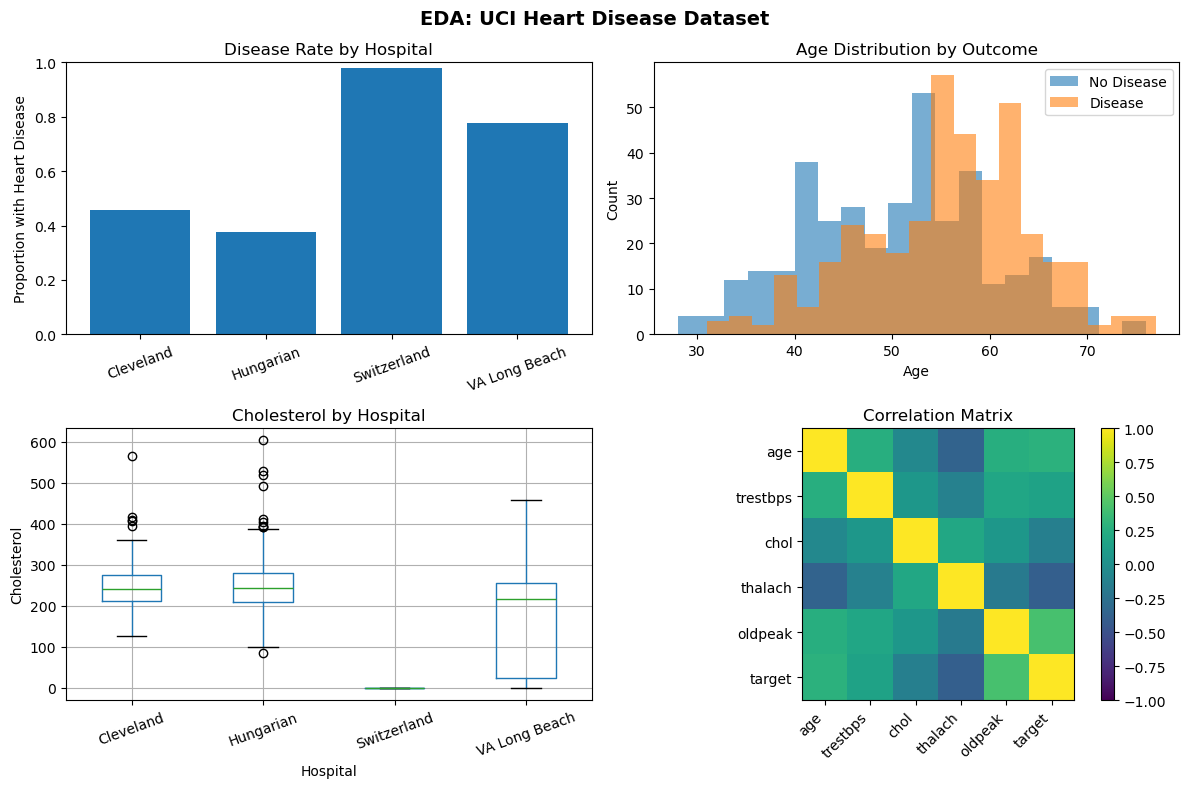

EDA plot saved to eda.png

Frequentist Logistic Regression (5-fold CV):
  ROC-AUC: 0.858 ± 0.038
  Accuracy: 0.769 ± 0.046

Fitting Complete Pooling model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...



Fitting No Pooling model...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 24 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...



Fitting Hierarchical model...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_offset, beta]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.



DIAGNOSTICS: Complete Pooling

R-hat summary:
  alpha: max R-hat = 1.0018 [OK]
  beta: max R-hat = 1.0030 [OK]

Divergences: 0

Effective Sample Size:
  alpha: min ESS = 7886 [OK]
  beta: min ESS = 5527 [OK]


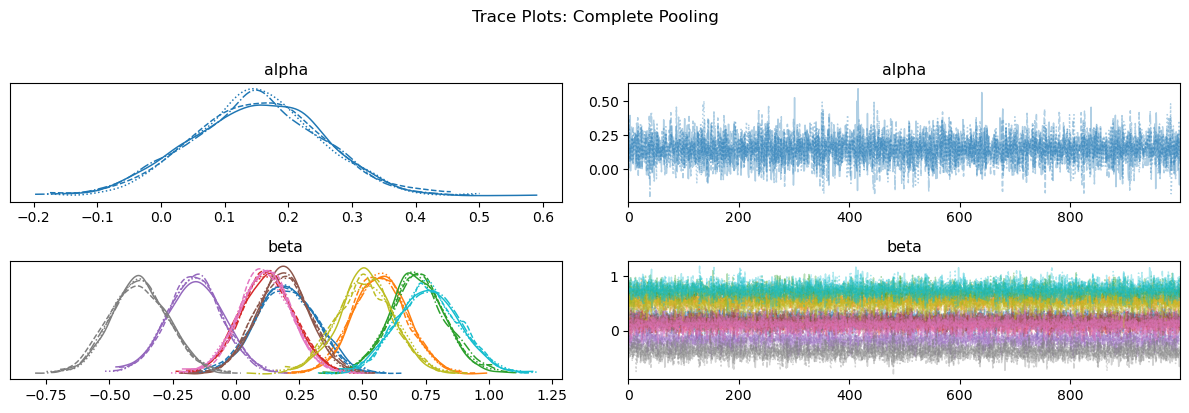

Trace plot saved to trace_complete_pooling.png

DIAGNOSTICS: No Pooling

R-hat summary:
  alpha: max R-hat = 1.0037 [OK]
  beta: max R-hat = 1.0030 [OK]

Divergences: 24

Effective Sample Size:
  alpha: min ESS = 2058 [OK]
  beta: min ESS = 2579 [OK]


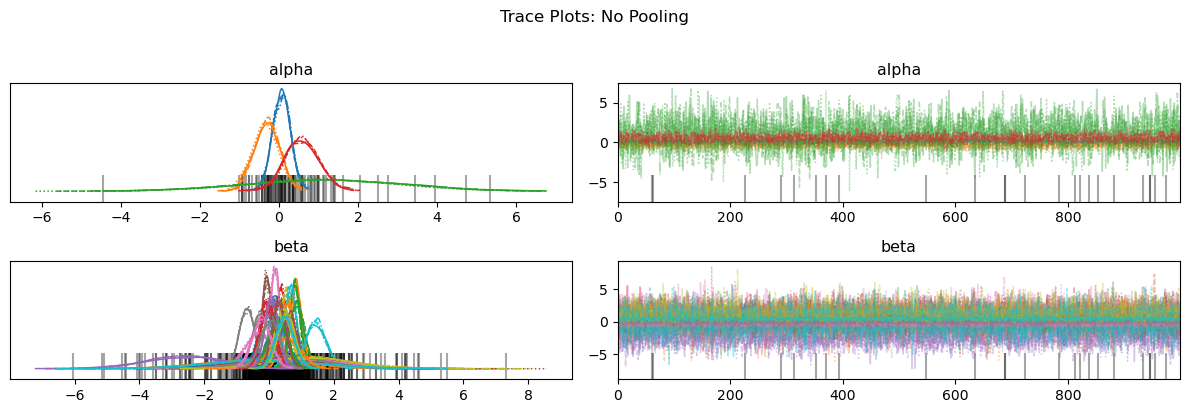

Trace plot saved to trace_no_pooling.png

DIAGNOSTICS: Hierarchical

R-hat summary:
  mu_alpha: max R-hat = 1.0011 [OK]
  alpha_offset: max R-hat = 1.0010 [OK]
  beta: max R-hat = 1.0011 [OK]
  sigma_alpha: max R-hat = 1.0000 [OK]
  alpha: max R-hat = 1.0012 [OK]

Divergences: 0

Effective Sample Size:
  mu_alpha: min ESS = 2656 [OK]
  alpha_offset: min ESS = 2681 [OK]
  beta: min ESS = 9266 [OK]
  sigma_alpha: min ESS = 4952 [OK]
  alpha: min ESS = 8236 [OK]


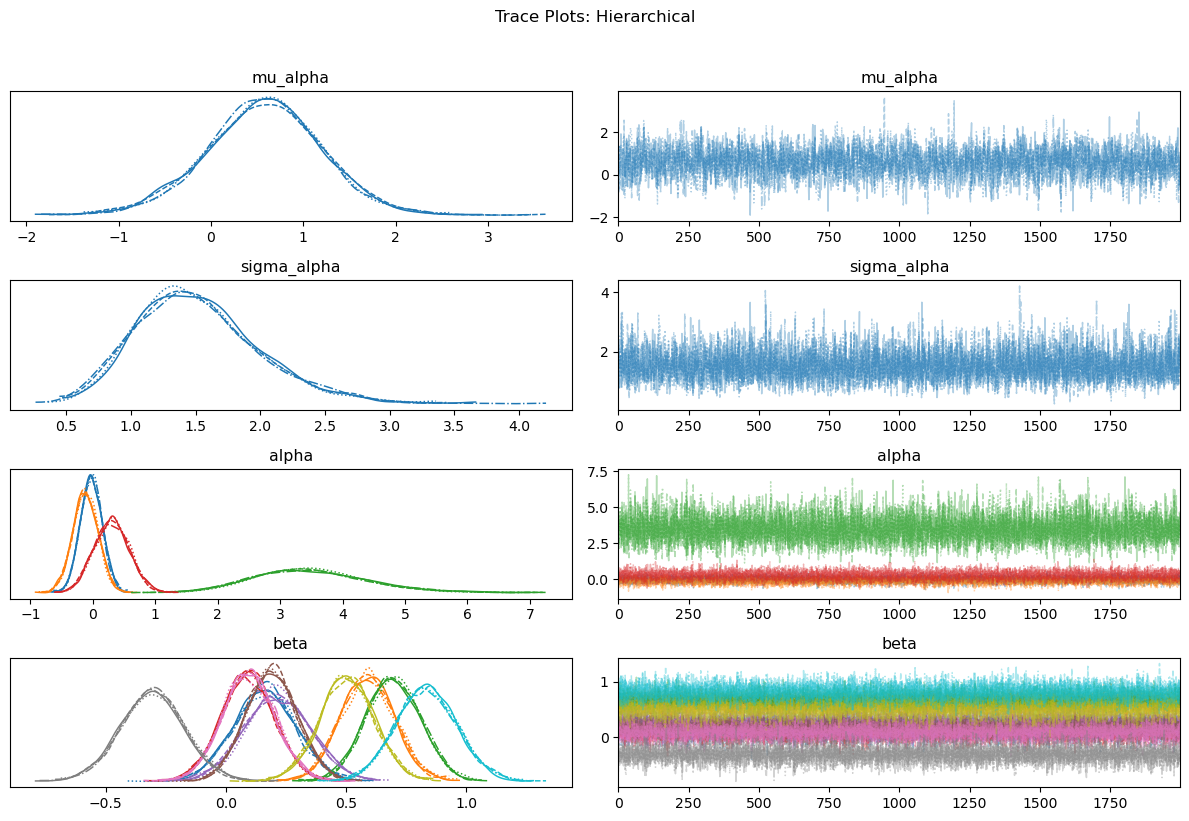

Trace plot saved to trace_hierarchical.png

MODEL COMPARISON: LOO-CV
                  rank    elpd_loo      p_loo  elpd_diff    weight         se  \
Hierarchical         0  630.920827  14.508105   0.000000  0.781143  31.994125   
No Pooling           1  655.896375  41.973160  24.975548  0.211094  37.324395   
Complete Pooling     2  660.473703  12.040750  29.552877  0.007762  32.226108   

                        dse  warning     scale  
Hierarchical       0.000000    False  deviance  
No Pooling        13.846835     True  deviance  
Complete Pooling   9.664579    False  deviance  


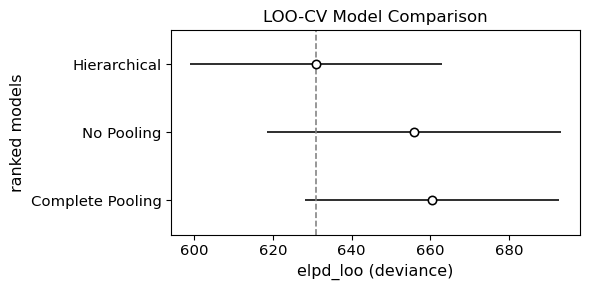

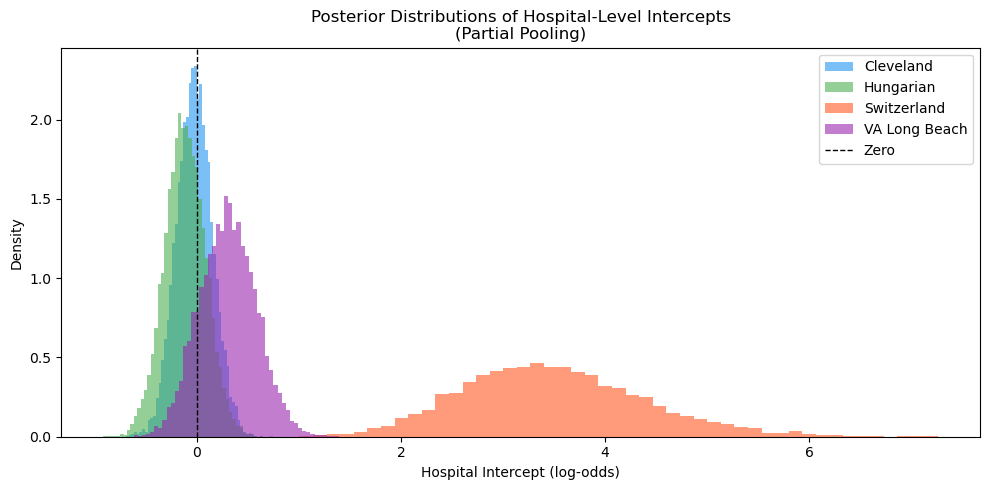

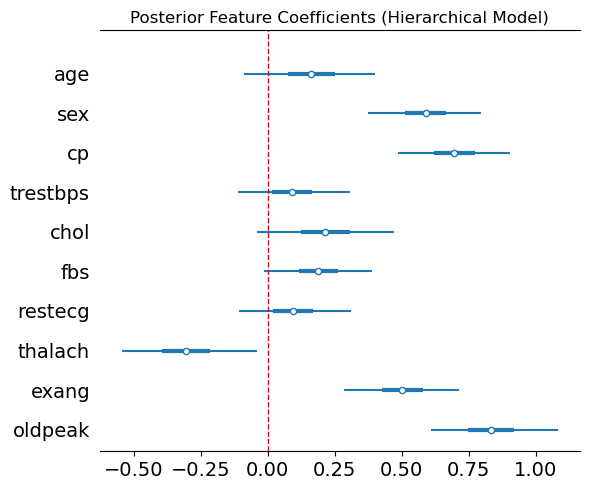

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
mu_alpha     0.575  0.625  -0.620    1.747      0.012    0.008   2655.721   
sigma_alpha  1.519  0.480   0.653    2.403      0.007    0.006   4952.022   
alpha[0]    -0.026  0.175  -0.343    0.310      0.002    0.002   8235.969   
alpha[1]    -0.119  0.200  -0.503    0.250      0.002    0.002   8351.231   
alpha[2]     3.489  0.897   1.864    5.200      0.010    0.010   8565.056   
alpha[3]     0.302  0.278  -0.200    0.833      0.003    0.003  10208.630   
beta[0]      0.161  0.130  -0.088    0.399      0.001    0.001   9614.836   
beta[1]      0.589  0.113   0.375    0.795      0.001    0.001  12190.003   
beta[2]      0.696  0.113   0.484    0.904      0.001    0.001   9730.054   
beta[3]      0.091  0.110  -0.110    0.305      0.001    0.001   9265.920   
beta[4]      0.215  0.136  -0.042    0.472      0.001    0.002   9803.640   
beta[5]      0.190  0.107  -0.012    0.387      0.001    0.001  11562.897   

In [19]:
#To make it easier to run most important plots on one, the code below is isolated. 
feature_cols = ["age", "sex", "cp", "trestbps", "chol",
                "fbs", "restecg", "thalach", "exang", "oldpeak"]

data, hospital_names = load_data()
n_hospitals = len(hospital_names)

plot_eda(data, hospital_names)

X = data[feature_cols].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = data["target"].values
hospital = data["hospital"].values

frequentist_baseline(X, y)

print("\nFitting Complete Pooling model...")
cp_model, cp_trace = complete_pooling_model(X, y, hospital, n_hospitals)
az.to_netcdf(cp_trace, "cp_trace.nc")

print("\nFitting No Pooling model...")
np_model, np_trace = no_pooling_model(X, y, hospital, n_hospitals)
az.to_netcdf(np_trace, "np_trace.nc")

print("\nFitting Hierarchical model...")
hier_model, hier_trace = hierarchical_model(X, y, hospital, n_hospitals)
az.to_netcdf(hier_trace, "hierarchical_trace.nc")

run_diagnostics(cp_trace, "Complete Pooling")
run_diagnostics(np_trace, "No Pooling")
run_diagnostics(hier_trace, "Hierarchical")

compare_models({
    "Hierarchical": hier_trace,
    "Complete Pooling": cp_trace,
    "No Pooling": np_trace,
})

plot_hospital_effects(hier_trace, hospital_names)
plot_feature_coefficients(hier_trace, feature_cols)

print(az.summary(hier_trace, var_names=["mu_alpha", "sigma_alpha", "alpha", "beta"], round_to=3))
